In [2]:
# os
import os
import sys
from os.path import join as join_path

# Computations
import numpy as np
import scipy as sp
import sympy as smp

# Science
import CoolProp.CoolProp as CP

# System
import yaml

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Data handling
import pandas as pd


In [3]:
# Initialization


# Plotting
sns.set_theme()
plt.rcParams['text.usetex'] = True

# Logging
np.set_printoptions(threshold=np.iinfo(np.intp).max)  # Show all elements
np.set_printoptions(linewidth=80)    # Optional: avoid line breaks
jupyter_stdout = sys.stdout
sys.stdout = open("wave_maker_theory.log", "a")

# paths
if __name__ == "__main__":  # Should be run from inside the project!!!
    # project name
    PROJECT_NAME = "ProjectAquarium"

    path = os.getcwd()
    while True:
        if os.path.basename(path) == PROJECT_NAME:
            PROJECT_PATH = path
            break

        parent = os.path.dirname(path)
        if parent == path:
            raise RuntimeError("ProjectAquarium not found")

        path = parent
PATH_FIGURES = "figures"
PATH_DATA = "data"


In [4]:
# aliases
norm = sp.linalg.norm
pi = np.pi

# Indices
XIND = 0
YIND = 1

Z_MAX = 0

# Physical parameters
with open(join_path(PROJECT_PATH, "design", "existing_parts.yaml"), "r") as file:
    aquarium_params = yaml.safe_load(file)["aquarium"]

# aquarium_params
H = aquarium_params["main_box"]["z_inner"] / 1000   # convert to meters
H = H/2     # actual depth of water

In [5]:
# constants (SI)
g0 = sp.constants.g     # At sea level
p0 = sp.constants.atm   # At sea level
T_room = 290            # ~ Israeli winter temperature in Kelvin

seasurface_density = CP.PropsSI('D', 'T', T_room, 'P', p0, 'Water')
viscosity = CP.PropsSI('VISCOSITY', 'T', T_room, 'P', p0, 'Water')  # Pa.s
kinematic_viscosity = viscosity / seasurface_density
seawater_surface_tension = 0.074  # N/m, estimate for seawater, +-0.001

# aliases
rho = seasurface_density
mu = viscosity
nu = kinematic_viscosity
tau = seawater_surface_tension


In [6]:
print("density = ", rho, "\nsurface_tension = ", tau)

## complex dispersion == dispersion + damping

In [7]:
# Dispersion relation, capillary-gravity, short waves limit.
def dr_cg_sw(k):
    k = norm(k, axis=-1)
    return np.sqrt((g0 * k + tau/rho * k**3))

In [31]:
N = int(2e3)
k_max = 2*np.pi*int(2e2)    # rad/m
k_ps = np.linspace(k_max/N, k_max, num=N).reshape((N,1))
k_ps_abs = norm(k_ps, axis=-1)

In [70]:
# See https://journals.aps.org/prfluids/pdf/10.1103/PhysRevFluids.3.124803 for details about the model.
def complex_dispersion(omega, k):
    lhs = (2 - 1j*omega/(nu*k**2))**2 + (k*(g0 + tau/rho * k**2)) / (nu**2 * k**4)
    rhs = 4 * np.sqrt(1 - 1j*omega/(nu*k**2))
    return lhs - rhs

# --- Solver for one k ---
def solve_for_k(k):
    # initial guess: inviscid dispersion relation
    k_abs = norm(k, axis=-1)
    omega0 = np.sqrt(g0*k_abs + (tau/rho) * k_abs**3)
    # solve numerically
    sol = sp.optimize.newton(func=lambda w: complex_dispersion(w, k_abs), x0=omega0, maxiter=1000, tol=1e-10)
    return sol

omegas = np.array([solve_for_k(k) for k in k_ps])


In [33]:
frequencies = np.real(omegas)/(2*pi)
decay_rates = np.imag(omegas)

In [34]:
# alternative no decay

ks_abs_alt = np.zeros(len(omegas))

for i in range(N):
    f = frequencies[i]
    def dispersion_kp(k):
        return (g0*k + (tau/rho)*k**3)*np.tanh(H*k) - (2*pi*f)**2

    if f < 13.45: 
        k_p_guess = (2*pi*f)**2 / g0
    else:
        k_p_guess = ((2*pi*f)**2 * rho/tau)**(1/3)
    k_lbound = k_p_guess/3
    k_rbound = 3*k_p_guess

    sol = sp.optimize.root_scalar(
        dispersion_kp, x0=k_p_guess, 
        bracket=[k_lbound, k_rbound],
        method="brentq"
        )

    # error checking
    if not sol.converged:
        raise RuntimeError(f"Root not found for k_p")
    ks_abs_alt[i] = sol.root


### dispersion (inverted): wavenumber vs. frequency

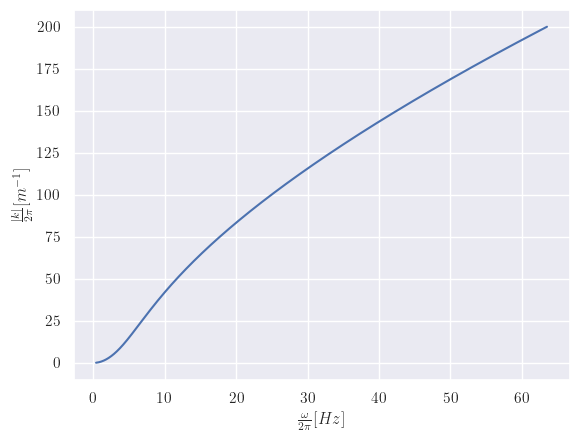

In [53]:
max_k_mm = k_ps_abs[-1]/(2*np.pi)
fig, ax = plt.subplots()
ax.plot(frequencies, k_ps_abs/(2*np.pi))
# plt.xlim(5, 50)
ax.set_xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 1.8)
ax.set_ylabel(r"$\frac{|k|}{2\pi} [m^{-1}]$")

# current_ticks = list(ax.get_yticks())
# current_ticks.append(max_k_mm)
# ax.set_yticks(current_ticks)

plt.savefig(
    fname=join_path(PATH_FIGURES, "g-c_waves_dispersion.png")
    )

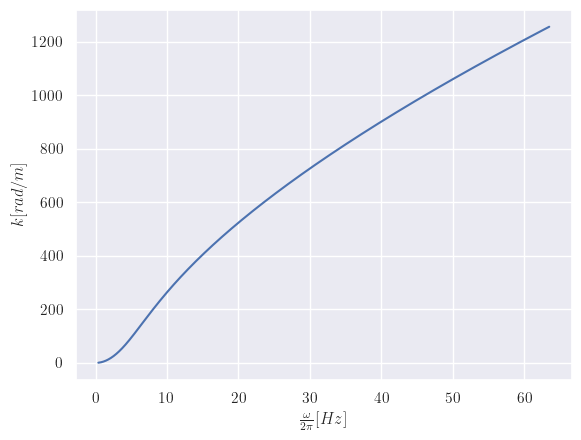

In [40]:
max_k_mm = k_ps_abs[-1]
fig, ax = plt.subplots()
ax.plot(frequencies, k_ps_abs)
# plt.xlim(5, 50)
ax.set_xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 1.8)
ax.set_ylabel(r"$k [rad/m]$")

# current_ticks = list(ax.get_yticks())
# current_ticks.append(max_k_mm)
# ax.set_yticks(current_ticks)

plt.savefig(
    fname=join_path(PATH_FIGURES, "g-c_waves_dispersion.png")
    )

In [87]:
3*2*pi

18.84955592153876

### Order of magnitude estimations

(5.0, 50.0)

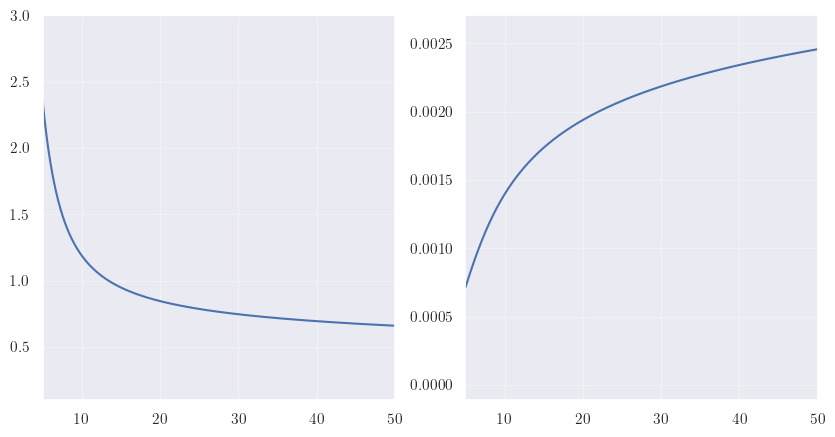

In [89]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
w_ref = 84.45
k_ref = 363.8
ax[0].plot(frequencies, np.real(np.sqrt(omegas)/k_ps_abs) / (np.sqrt(w_ref)/k_ref))
ax[0].grid(alpha=0.3, which='both')
ax[0].set_xlim(5,50)
ax[0].set_ylim(0.1,3)
ax[1].plot(frequencies, -np.imag(np.sqrt(omegas)/k_ps_abs) / (np.sqrt(w_ref)/k_ref))
ax[1].grid(alpha=0.3, which='both')
ax[1].set_xlim(5,50)
# ax[0].set_ylim(0.1,4)


(5.0, 60.0)

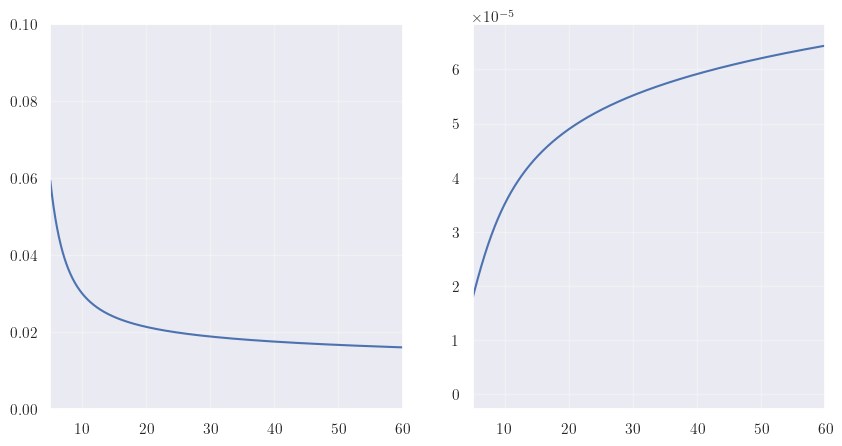

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
w_ref = 84.45
k_ref = 363.8
ax[0].plot(frequencies, np.real(np.sqrt(omegas)/k_ps_abs))
ax[0].grid(alpha=0.3, which='both')
ax[0].set_xlim(5,60)
ax[0].set_ylim(0,0.1)
ax[1].plot(frequencies, -np.imag(np.sqrt(omegas)/k_ps_abs))
ax[1].grid(alpha=0.3, which='both')
ax[1].set_xlim(5,60)


np.float64(24.24756181896712)

### Wave excitation

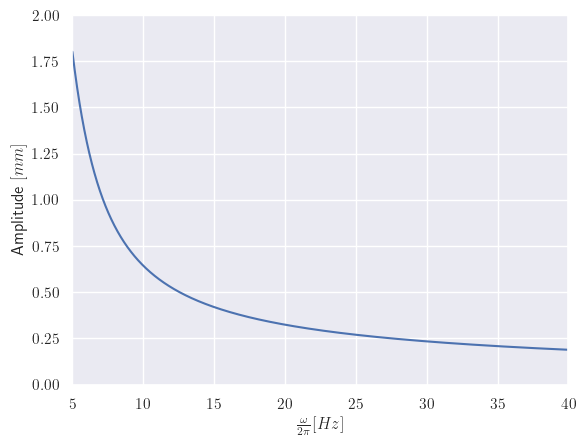

In [12]:
wavelengths = (2*np.pi) / k_ps_abs
rms_slopes = 0.12 * np.ones(len(wavelengths))
amplitudes = rms_slopes * np.sqrt(2) * wavelengths / (2*pi)
print("wavelength_to_amplitude = ", rms_slopes[0] * np.sqrt(2) / (2*pi))


plt.plot(frequencies, 1000 * amplitudes)   # mm
plt.xlim(5, 40)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 2)
plt.ylabel(r"Amplitude $[mm]$")

plt.savefig(
    fname=join_path(PATH_FIGURES, "g-c_wavelengths.png")
    )

In [13]:
amplitudes[frequencies < 41][-1] * 1000

np.float64(0.1848698801143955)

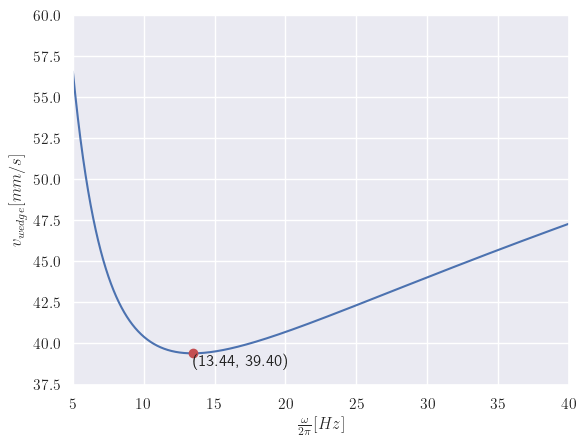

In [14]:
# nonlinear_correction = 2 * rms_slopes**2    # Lamb 1945, at Zappa et al (2008), results
peak_vertical_velocity = 2*pi * frequencies * amplitudes

plt.plot(frequencies, 1000*peak_vertical_velocity)
plt.xlim(5, 40)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(37.5, 60)
plt.ylabel(r"$v_{wedge} [mm/s]$")
i_min = np.argmin(peak_vertical_velocity)
w_min = frequencies[i_min]
v_min = peak_vertical_velocity[i_min]
plt.plot([w_min], [1000*v_min], 'ro')
plt.text(w_min, 1000*v_min, f"({w_min:.2f}, {1000*v_min:.2f})", fontsize=12, ha='left', va='top')
plt.savefig(fname=join_path(PATH_FIGURES, "wavemaker_peak_velocity.png"))

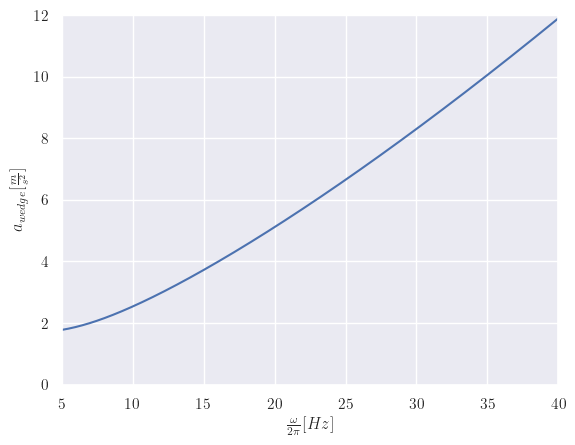

In [15]:
peak_accelaration = 2*pi * frequencies * peak_vertical_velocity # estimation

plt.plot(frequencies, peak_accelaration)
plt.xlim(5, 40)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 12)
plt.ylabel(r"$a_{wedge} [\frac{m}{s^2}]$")

plt.savefig(fname=join_path(PATH_FIGURES, "wavemaker_peak_accelaration.png"))

In [16]:
i_f_is_5 = np.argmin((frequencies - 5)**2)
i_f_is_30 = np.argmin((frequencies - 30)**2)

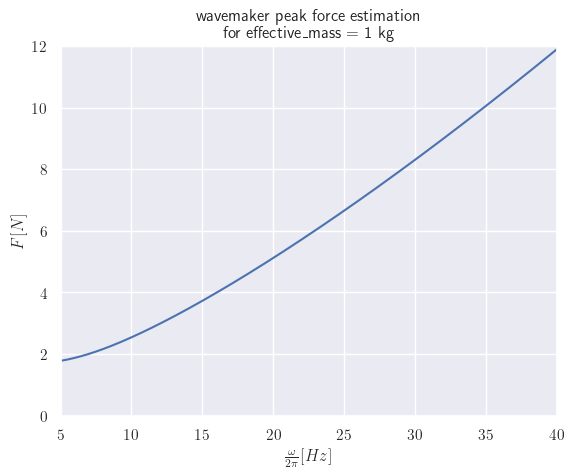

In [17]:
m_eff = 1   # kg; estimation
peak_force = peak_accelaration * m_eff

plt.plot(frequencies, peak_force)
plt.xlim(5, 40)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 12)
plt.ylabel(r"$F [N]$")
plt.title(f"wavemaker peak force estimation\nfor effective_mass = {m_eff} kg")
plt.savefig(fname=join_path(PATH_FIGURES, f"wavemaker_peak_force_estimation_{m_eff}_kg.png"))

Text(0.5, 0.5, 'f =           30\nwavelength =  8.7\nA =           0.23\nv =           44\nF =           8.3\n')

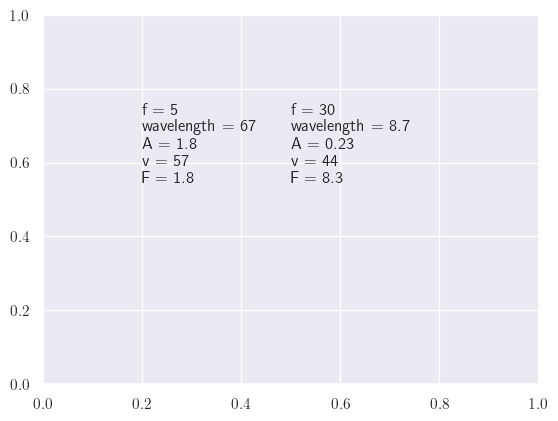

In [18]:
plt.figure()
plt.text(0.2, 0.5,
        f"f =           {frequencies[i_f_is_5]:.2g}\n"
        f"wavelength =  {1000*wavelengths[i_f_is_5]:.2g}\n"
        f"A =           {1000*amplitudes[i_f_is_5]:.2g}\n"
        f"v =           {1000*peak_vertical_velocity[i_f_is_5]:.2g}\n"
        f"F =           {peak_force[i_f_is_5]:.2g}\n"
        )

plt.text(0.5, 0.5,
        f"f =           {frequencies[i_f_is_30]:.2g}\n"
        f"wavelength =  {1000*wavelengths[i_f_is_30]:.2g}\n"
        f"A =           {1000*amplitudes[i_f_is_30]:.2g}\n"
        f"v =           {1000*peak_vertical_velocity[i_f_is_30]:.2g}\n"
        f"F =           {peak_force[i_f_is_30]:.2g}\n"
        )

### group velocity vs. frequency

Text(6.393221655171044, 178.32751699172914, '(6.39, 178.33)')

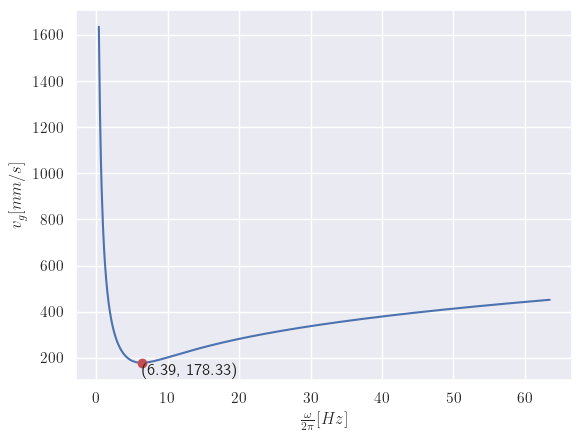

In [19]:
dwdks = np.diff(frequencies)/np.diff(norm(k_ps, axis=-1)/(2*np.pi))
plt.plot(frequencies[:-1], 1000*dwdks)
# plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0,0.1)
plt.ylabel(r"$v_g [mm/s]$")
i_min = np.argmin(dwdks)
w_min = frequencies[i_min]
v_min = dwdks[i_min]
plt.plot([w_min], [1000*v_min], 'ro')
plt.text(w_min, 1000*v_min, f"({w_min:.2f}, {1000*v_min:.2f})", fontsize=12, ha='left', va='top')


### Bond number vs. frequency

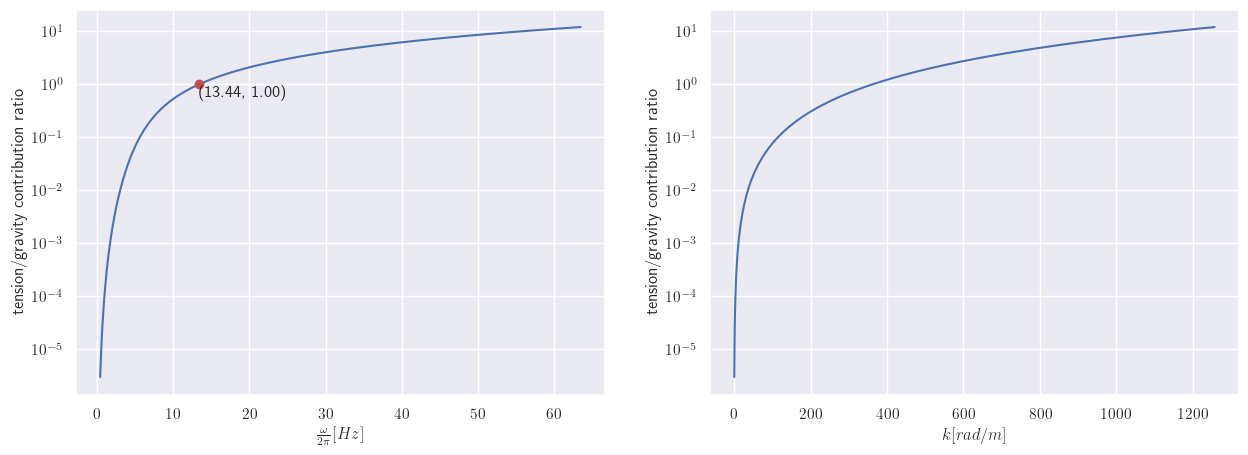

In [61]:
fig, ax = plt.subplots(figsize=(15, 5), ncols=2)
Bo = rho*g0 / (tau * k_ps**2)
ax[0].semilogy(frequencies, 1/Bo)
i_equal = np.argmin((Bo-1)**2)
f_equal = frequencies[i_equal]
Bo_equal = Bo[i_equal][0]
print(Bo_equal)
ax[0].semilogy([f_equal], [Bo_equal], 'ro')
ax[0].text(f_equal, Bo_equal, f"({f_equal:.2f}, {Bo_equal:.2f})", fontsize=12, ha='left', va='top')
# plt.xlim(0, 40)
# plt.ylim(0, 7)
ax[0].set_xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
ax[0].set_ylabel("tension/gravity contribution ratio")

ax[1].semilogy(k_ps_abs, 1/Bo)
ax[1].set_xlabel(r"$k [rad/m]$")
ax[1].set_ylabel("tension/gravity contribution ratio")

print(r"$k_{equal} = $", np.sqrt(rho*g0/tau), "rad/m")
print(r"$\omega_{equal} = $", f_equal*2*pi, "rad/s")

Text(0, 0.5, 'tension - gravity contribution ratio')

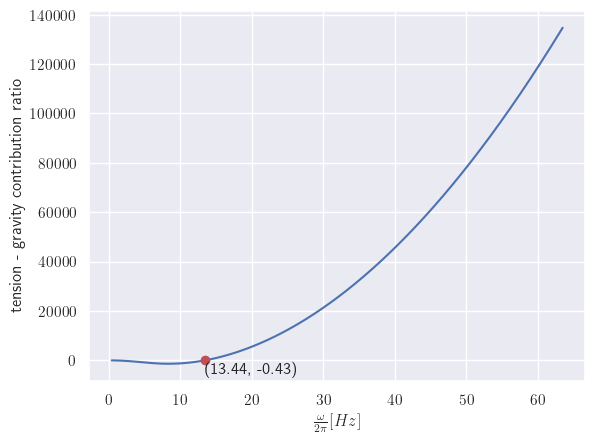

In [21]:
# yet another tension vs gravity comparison graph
c_g_diff = tau/rho * k_ps_abs**3 - g0 * k_ps_abs
plt.plot(frequencies, c_g_diff)
i_equal = np.argmin(c_g_diff[frequencies<20]**2)
f_equal = frequencies[i_equal]
c_g_diff_equal = c_g_diff[i_equal]
plt.plot([f_equal], [c_g_diff_equal], 'ro')
plt.text(f_equal, c_g_diff_equal, f"({f_equal:.2f}, {c_g_diff_equal:.2f})", fontsize=12, ha='left', va='top')
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylabel("tension - gravity contribution ratio")

### phase velocity vs frequency

Text(0, 0.5, '$v_{phase}[m/s]$')

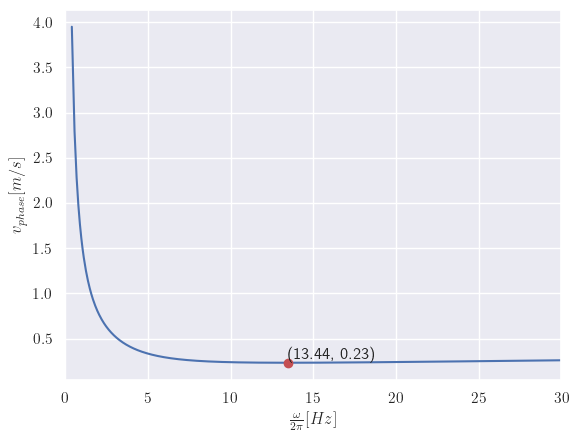

In [23]:
N = int(1e3)
k_max = 2*np.pi*int(1e3)
vs = np.real(omegas)/norm(k_ps, axis=-1)
plt.plot(frequencies, vs)

i_min = np.argmin(vs)
w_min = frequencies[i_min]
v_min = vs[i_min]
plt.plot([w_min], [v_min], 'ro')
plt.text(w_min, v_min, f"({w_min:.2f}, {v_min:.2f})", fontsize=12, ha='left', va='bottom')

plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
# plt.ylim(0, 120/100)
plt.ylabel(r"$v_{phase}[m/s]$")

### decay rate vs. frequency

Text(0, 0.5, '$\\alpha \\left[s^{-1}\\right]$')

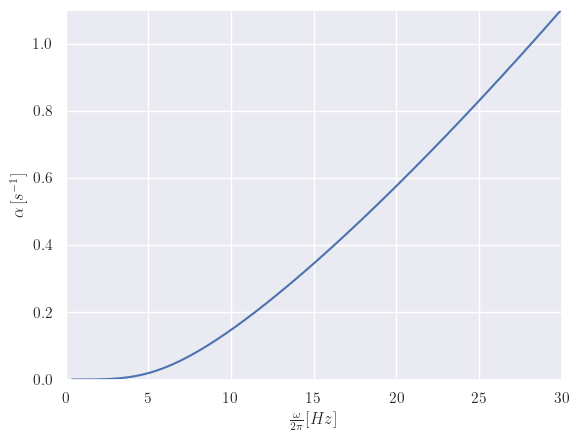

In [22]:
plt.plot(np.real(omegas)/(2*np.pi), -np.imag(omegas))
plt.xlim(0, 30)
plt.xlabel(r"$\frac{\omega}{2\pi} [Hz]$")
plt.ylim(0, 1.1)
plt.ylabel(r"$\alpha \left[s^{-1}\right]$")

Text(0, 0.5, '$\\alpha \\left[s^{-1}\\right]$')

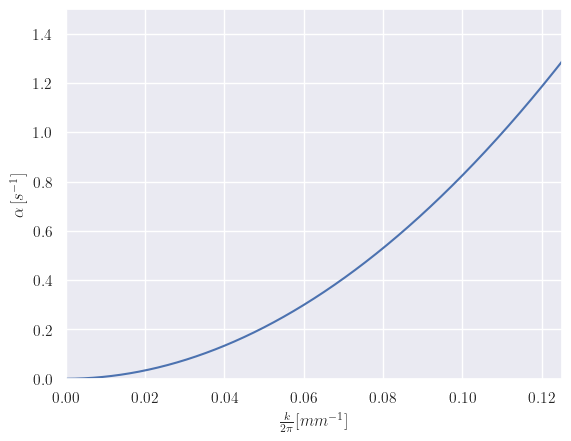

In [23]:
plt.plot(k_ps_abs/(1000*2*np.pi), -np.imag(omegas))
plt.xlim(0, 0.125)
plt.xlabel(r"$\frac{k}{2\pi} [mm^{-1}]$")
plt.ylim(0, 1.5)
plt.ylabel(r"$\alpha \left[s^{-1}\right]$")

# Wave making theory

### evanescent modes

Text(0.5, 0, 'wavenumber $[mm^{-1}]$')

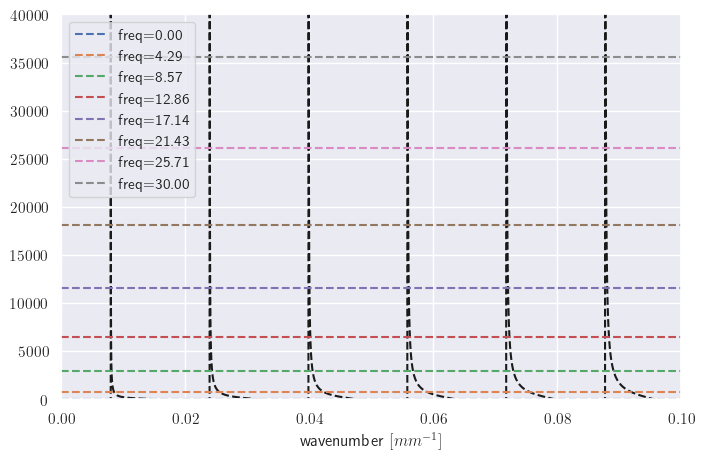

In [24]:
n_dense = int(1e5)
k_max = 2*np.pi*int(1e2) # m^-1
ks_dense = np.linspace(k_max/n_dense, k_max, num=n_dense).reshape((n_dense,1))
f_max = 30  # Hz


plt.figure(figsize=(8,5))

ks_dense_abs = norm(ks_dense, axis=-1)
plt.plot(
    ks_dense_abs/1000,   # mm^-1
    (tau/rho * ks_dense_abs**3 - g0*ks_dense_abs)*np.tan(ks_dense_abs*H),
    '--k')

df = frequencies[-1]/n_dense
N = 8
freqs = np.linspace(df, f_max, num=N)
for i in range(N):
    freq = freqs[i]
    k = ks_dense_abs[i]
    plt.plot([0, k_max], [(2*pi*freq)**2]*2, '--', label=fr"freq={freq:.2f}")
# label=fr"$f_p = {freq:.2f}Hz$"
plt.legend()
plt.xlim(0, 0.1)
plt.ylim(0, 4e4)
plt.xlabel(r"wavenumber $[mm^{-1}]$")

This seems to mean that 300mm away from the wave maker, all but the first
evanescent mode disappear. E.g. the second mode has $k \approx 0.012mm^{-1}$, so 
$k \cdot 30cm \approx 3.6$, which means that the mode decayed by a factor of
$e^{-3.6} \approx 2\%$ of the original amplitude. The first mode, on the other 
hand, seems to be at $k \approx 0.04cm^{-1}$ and so $k \cdot 300mm \approx 1.2$, 
which is still dominant with $70\%$ amplitude loss. The traveling mode, on the
other hand, say at the transition point with $\frac{\omega}{2 \pi} = 13.47Hz$ 
and $v_{phase} \approx 230\frac{mm}{s}$ has $\alpha \approx 0.3s^{-1}$, which 
means that at $30cm$ it has lost about $33\%$ of its amplitude, which is not too
bad. At $20Hz$, on the other hand, $\alpha \approx 0.6$ and the mode lost 
$\approx 50\%$ of its initial amplitude.

## mode amplitude distribution

variables: \omega_p, \alpha, d, S, M, N
parameters: h=H
remark: I do *not* normalize the height by H, so z is expected to be in the
range -H to 0.
remark: we work in the deep water limit, so tanh(h k_p) is dropped in the
expression for the dispersion (computation of k_p), and cosh(k_p (h + z)),
sinh(z (h + z)) are replaced with e^{k_p (h + z)} in compuing the travelin part 
of the velocity potential expression. I also extract e^{-h K_p} from A_p, 
A_{e,s}, for numerics sake.

In [25]:
def get_transition_point(rho=seasurface_density, tau=seawater_surface_tension):
    return np.sqrt(rho*g0/tau)

In [26]:
def alpha_func(z, d, alpha, h=H):
    """
    Piecewise alpha function.
    """
    z = np.asarray(z)
    a_per_z = np.empty_like(z, dtype=float)
    mask1 = (-d <= z) & (z <= 0)
    mask2 = (-h <= z) & (z < -d)

    a_per_z[mask1] = alpha
    a_per_z[mask2] = 0

    if not np.all(mask1 | mask2):
        raise ValueError("z out of range")
    
    return a_per_z.item() if np.isscalar(z) else a_per_z

# Propagating wave number k_p
def get_kp(w_p, tau=seawater_surface_tension):
    def dispersion_kp(k):
        return (g0*k + (tau/rho)*k**3) - w_p**2
    
    k_p_guess = w_p**2 / g0
    k_p_lbound = 0
    k_p_rbound = 1e4

    sol = sp.optimize.root_scalar(
        dispersion_kp, x0=k_p_guess, 
        bracket=[k_p_lbound, k_p_rbound],
        method="brentq"
        )

    # error checking
    if not sol.converged:
        raise RuntimeError(f"Root not found for k_p")

    return sol.root

# Evanescent modes k_{s,n}
def get_k_ns(N, w_p, rho=seasurface_density, tau=seawater_surface_tension, h=H):
    def decay_kn(k):
        return (-g0*k + (tau/rho)*k**3)*np.tan(k*h) - w_p**2

    k_equal = get_transition_point(rho, tau)
    k_ns = np.zeros(N)
    
    for n in range(1, N+1):
        # Approx first guess
        delta = pi / (4*h)
        if (n-1/2)*pi/h < k_equal:
            k_guess = (n-1/4)*np.pi/h   # tan is decreasing to the right
            k_lbound  = k_guess - delta * (1-1e-3)
            k_rbound = k_guess + delta * (1+1e-3) 
        else:
            k_guess = (n-3/4)*np.pi/h   # tan is decreasing to the left
            k_lbound  = k_guess - delta * (1+1e-3)
            k_rbound = k_guess + delta * (1-1e-3) 
                
        # print(k_lbound, k_rbound)
        # print((-g0*k_lbound + (tau/rho)*k_lbound**3)*np.tan(k_lbound*h) - w_p**2)
        # print((-g0*k_rbound + (tau/rho)*k_rbound**3)*np.tan(k_rbound*h) - w_p**2)

        # find 0
        sol = sp.optimize.root_scalar(
            decay_kn, x0=k_guess, bracket=[k_lbound, k_rbound], method="brentq"
            )
        
        # error checking
        if not sol.converged:
            raise RuntimeError(f"Root not found for n={n}")
        
        k_ns[n-1] = sol.root
        
    return k_ns

def B_m0(z_ms, k_p, a, d, h=H):
    return k_p/2 * (
            - np.tan(a) * (np.exp(k_p * z_ms) - np.exp(-k_p * (z_ms + 2*h)))
            + 1j * (np.exp(k_p * z_ms) + np.exp(-k_p * (z_ms + 2*h)))
        ) * np.exp(
            1j * k_p * np.tan(a) * (d + z_ms)
        )

def B_mn(z_m, k_n, a, d, h=H):
    return -k_n * (
        np.cos(k_n * h * (1 + z_m/h)) 
        - np.tan(a) * np.sin(k_n * (h + z_m))
    ) * np.exp(-k_n * np.tan(a) * (d + z_m))

def get_zs(M, z_min=-H, z_max=0):
    zs = np.flip(np.linspace(z_min, z_max, M))
    return zs

def construct_B(z_ms, k_p, k_ns, alpha, d, h=H):
    ks_mesh, zs_mesh = np.meshgrid(k_ns, z_ms)
    a = alpha_func(z_ms, d, alpha)
    a_mesh = alpha_func(zs_mesh, d, alpha, h=H)
    B = np.zeros([len(z_ms), 1+len(k_ns)], dtype='complex')
    B[:,0] = B_m0(z_ms, k_p, a, d, h)
    B[:,1:] = B_mn(zs_mesh, ks_mesh, a_mesh, d, h)
    return B

def construct_D(z_ms, w_p, S, d, alpha, h=H):
    a = alpha_func(z_ms, d, alpha, h=h)
    return - S * w_p * np.tan(a)

def compute_A_exact(
        M:int, N: int,                                      # Numerical variables
        f_p:float, S:float, d: float,                       # Physical variables
        rho=seasurface_density, tau=seawater_surface_tension,
                                                            # Physical params
        alpha=pi/6, h=H,                                    # Setting params
        eps=1e-12                                           # Numerical params
        ):
    w_p = 2*pi*f_p
    z_ms = get_zs(M, z_min=-h, z_max=0)
    k_p = get_kp(w_p)
    k_ns = get_k_ns(N, w_p, rho, tau)
    # print(np.exp(k_p * (z_ms))[-1])
    z_ms = z_ms[np.exp(k_p * (z_ms-np.max(z_ms))) > eps]    # Truncate z_ms
    M = len(z_ms)                                           # Update M
    B = construct_B(z_ms, k_p, k_ns, alpha=alpha, d=d, h=h)
    D = construct_D(z_ms, w_p=w_p, S=S, d=d, alpha=alpha)
    A, res, rank, s = np.linalg.lstsq(B, D, rcond=None)
    A_df = pd.DataFrame(A)
    A_df.to_pickle(join_path(
        ".", PATH_DATA,
        f"A_vp_{M}_{N}_{f_p:.2g}_{S:.2g}_{d:.2g}_{eps:.2g}.pkl"))
    return A



In [27]:
stroke = 2e-3       # meters
mean_depth = 2e-3   # meters
f_plunger = 20    # Hz
w_plunger = 2*pi*f_plunger
wedge_tip_angle = pi/6
k_p = get_kp(2*pi*f_plunger)
eps = 1e-46

### convergence in vertical sample density

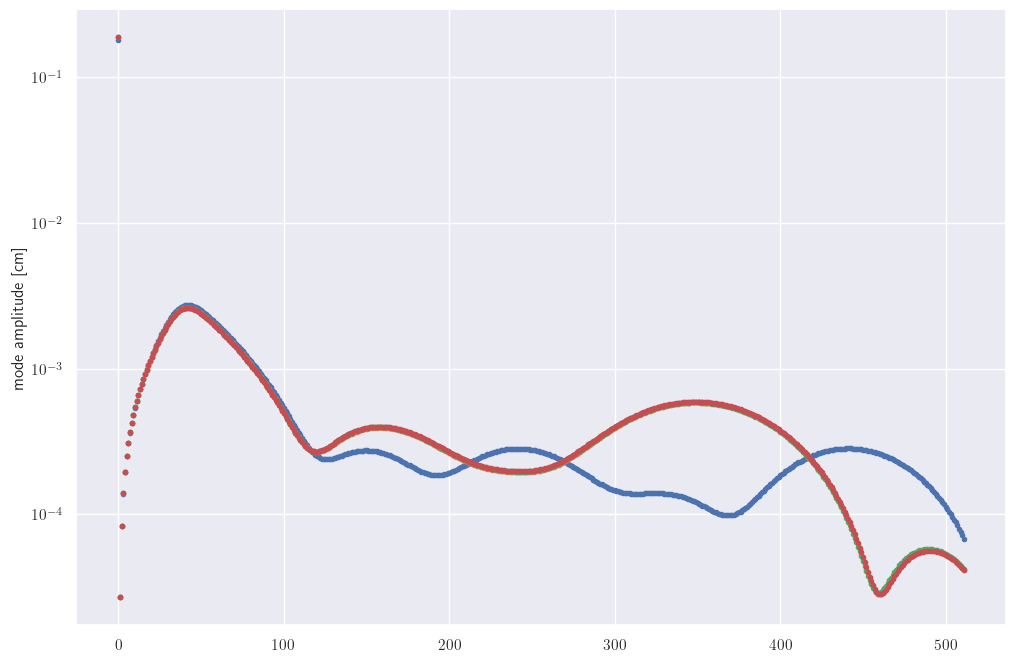

In [28]:
# Clear log:
open("wave_maker_theory.log", "w").close()

# Different vertical sample density for same total mode number:
plt.figure(figsize=(12,8))
N = 511
for M in [1e3, 1e4, 1e5, 4e5]:   

    k_ns_dense = get_k_ns(N, w_plunger)
    ks_dense = np.concatenate(([k_p], k_ns_dense))

    A_dense = compute_A_exact(
        M=int(M), N=N,
        f_p=f_plunger, S=stroke, d=mean_depth,
        alpha=wedge_tip_angle, h=H,
        eps=1e-46
        )
    mode_amplitudes_dense = np.abs(1j*(ks_dense/w_plunger)*A_dense)  # value in m

    plt.semilogy(mode_amplitudes_dense * 1e2, '.')   # print in cm.

    plt.ylabel(r"mode amplitude [cm]")
plt.savefig(join_path(
    PATH_FIGURES,
    f"mode_mag_{N}__{f_plunger:.2g}_{stroke:.2g}_{mean_depth:.2g}_{eps:.2g}.png"
    ))

### 

### convergence in number of modes

### 

In [29]:
# Clear log:
open("wave_maker_theory.log", "w").close()

M = 4e4
mode_amplitudes_dense = {}

# Differentvertical sample density for same total mode number:
plt.figure(figsize=(12,8))
for N in [127, 255, 511, 1023, 2047, 4095]:
    print(f"N = {N}", flush=True)
    k_ns_dense = get_k_ns(N, w_plunger)
    ks_dense = np.concatenate(([k_p], k_ns_dense))

    A_dense = compute_A_exact(
        M=int(M), N=N,
        f_p=f_plunger, S=stroke, d=mean_depth,
        alpha=wedge_tip_angle, h=H,
        eps=1e-46
        )

    mode_amplitudes_dense[N] = np.abs(1j*(ks_dense/w_plunger)*A_dense)  # value in m

<Figure size 1200x800 with 0 Axes>

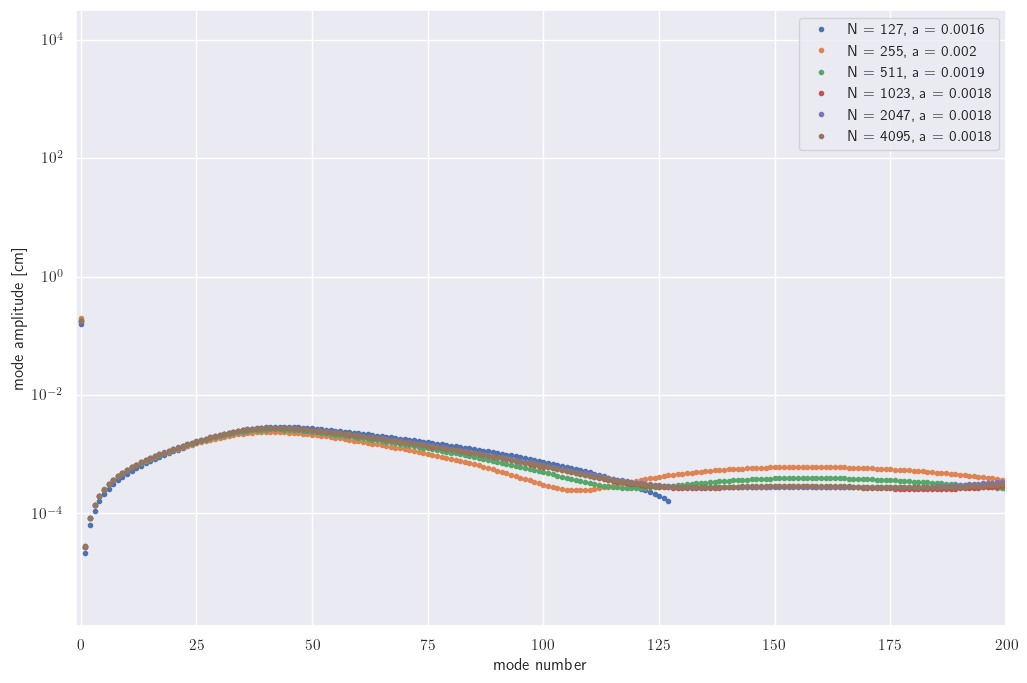

In [30]:
plt.figure(figsize=(12,8))
for N in [127, 255, 511, 1023, 2047, 4095]:
    a = mode_amplitudes_dense[N][0]
    plt.semilogy(
        mode_amplitudes_dense[N] * 1e2, '.', label=f"N = {N}, a = {a:.2g}"
        )   # print in cm.

    plt.legend()
    plt.xlabel(r"mode number")
    plt.ylabel(r"mode amplitude [cm]")
    plt.xlim(-1, 200)
plt.savefig(join_path(
    PATH_FIGURES,
    f"mode_mag_{M:.2g}_127-4095_{f_plunger:.2g}_{stroke:.2g}_{mean_depth:.2g}_{eps:.2g}.png"
    ))    

In [31]:
# compare to Wu's paper

A_p = A_dense[0]
a_p = mode_amplitudes_dense[4095][0]
A_p_Wu = A_p / (w_plunger * stroke * H)
ratio_Wu = np.abs(-1j * A_p_Wu * k_p * H)

sys.stdout = open("wave_maker_theory.log", "a")
print(f"A_p = {A_p:.2g}\ntraveling_mode_amplitude = {a_p:.2g}")
print(f"A_p_Wu = {A_p_Wu:.2g}\namplitude_Wu/S = {ratio_Wu:.2g}")
print(f"    compare\ntraveling_mode_amplitude/S = {a_p/stroke:.2g}")


In [32]:
omega = solve_for_k([k_p])

x_30cm = 0.3     # m
k_ns = get_k_ns(N, w_plunger)
a_30cm = np.zeros(N)
for n in range(N):
    a_30cm[n] = np.abs(
        1j*(k_p/w_plunger)*A_dense[0] * 1/2 * (1 + np.exp(-2*k_p*H)) * np.exp(1j*k_p*x_30cm)
            * np.exp(-np.abs(np.imag(omega) * k_p/np.real(omega) * x_30cm))
        + np.sum(1j*(k_ns[:n]/w_plunger)*A_dense[1:n+1] * np.cos(k_ns[:n]*H) * np.exp(-k_ns[:n]*x_30cm))
    )

In [33]:
k_p/np.real(omega)

np.float64(4.169749770462706)

In [34]:
np.exp(np.imag(omega) * k_p/np.real(omega) * x_30cm)

np.float64(0.4869687038366678)

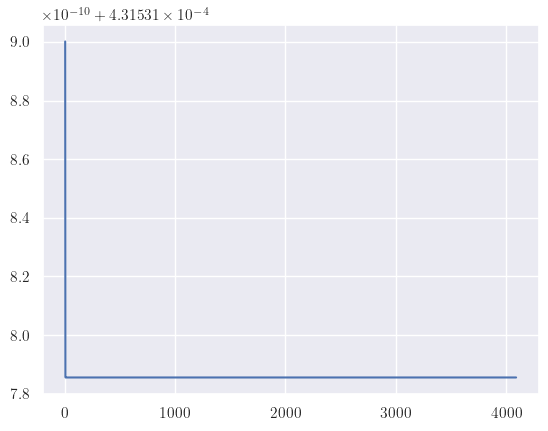

In [35]:
plt.plot(a_30cm)
# plt.xlim(0,5)

## Nonlinear theory

In [36]:
# parameters: n, s, rho, g, tau assumed real scalars
N_rs = 10
k_resonant_abs = np.zeros(N_rs, dtype="complex")
omega_resonant = np.zeros(N_rs, dtype="complex")
print(f"g = {g0}, rho = {rho}, tau = {tau}")
pairs = [(2,2), (3,3), (3,1)]
for i in range(len(pairs)):
    n, s = pairs[i]
    # if (n**2 - s**3 == 0):
    #     continue
    k_resonant_abs[i] = np.emath.sqrt(
        -((n**2 - s) / (n**2 - s**3)) * (g0 * rho) / tau
    )

    omega_resonant[i] = np.emath.sqrt(
        g0 * k_resonant_abs[i]
        + (tau / rho) * k_resonant_abs[i]**3
    )
    print(f"n = {n}, k/2pi = {k_resonant_abs[i]/(2*pi)}, w/2pi = {omega_resonant[i]/(2*pi)}")


/home/inbarm/ProjectAquarium/code/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/inbarm/ProjectAquarium/code/.venv/lib/python3.14/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Text(0, 0.5, 'spatial frequency [mm$^{-1}$]')

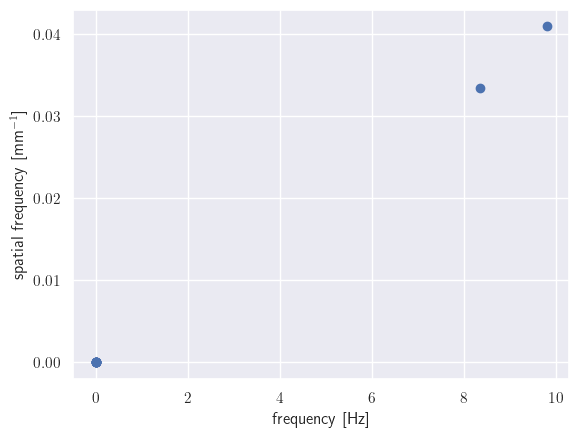

In [37]:
plt.plot(omega_resonant/(2*pi), k_resonant_abs/(2*pi*1000), 'o')
plt.xlabel("frequency [Hz]")
plt.ylabel(r"spatial frequency [mm$^{-1}$]")
# plt.xlim(0, 400)

I think that the above little calculation shows that we are to expect only two 
prominent Wilton ripples in our band.   

## archive


In [ ]:
# Example usage
B0 = B_m0(k_p, H, z_m, alpha_val, d)
Bn = B_mn(k_s_n, H, z_m, alpha_val, d)
D = D_m(S, omega_p, z_m, d, alpha_val)

# Amplitudes
A0 = A_p = 1.0
An = A_s_n = 0.5

In [ ]:
def dispersion_kp(k):
    return (g0*k + (tau/rho)*k**3)*np.tanh(k*H) - w_plunger**2

k_p_guess = w_plunger**2 / g0
delta = pi / (4*h) * (1-1e-3)
k_lbound  = k_p_guess - delta
k_rbound = k_p_guess + delta
# print(k_lbound, k_rbound)
# print((-g0*k_lbound + (tau/rho)*k_lbound**3)*np.tan(k_lbound*h) - w_p**2)
# print((-g0*k_rbound + (tau/rho)*k_rbound**3)*np.tan(k_rbound*h) - w_p**2)

# find 0
sol = sp.optimize.root_scalar(
    decay_kn, x0=k_guess, bracket=[k_lbound, k_rbound], method="brentq"
    )
k_p = sp.optimize.fsolve(dispersion_kp, x0=k_p_guess)[0]
g0*k*np.tanh(k_p*H) + (tau/rho)*k_p**3 - w_plunger**2

np.float64(-5137.218744908463)

In [2]:
complex(1, 5)

(1+5j)